In [31]:
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt

from xarch_tokenizers.logging.report_utils import load_predictions

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
base_dir = Path("../results/tokenization_robustness/").resolve().absolute()
base_dir.exists()
pred_files = list(base_dir.rglob("*predictions.json"))
pred_files

[PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/tokenization_robustness/Llama-3.1-8B-Instruct/mgsm-eval-Llama-3.1-8B-Instruct/predictions.json'),
 PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/tokenization_robustness/Qwen2.5-0.5B-Instruct/mgsm-eval-Qwen2.5-0.5B-Instruct/predictions.json'),
 PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/tokenization_robustness/Qwen2.5-7B-Instruct/mgsm-eval-Qwen2.5-7B-Instruct/predictions.json')]

In [51]:
all_preds = load_predictions(
    base_dir,
    patterns=["*7B*", "*8B*"],
    filters=None,
    metrics=["multi_target_match"],
    additional_docs=["tokenization_type", "category", "set_id", "tokenization_type"],
)
print(len(all_preds))

Processing predictions from 4: [PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/tokenization_robustness/Qwen2.5-7B-Instruct'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/tokenization_robustness/Qwen2.5-7B-Instruct/mgsm-eval-Qwen2.5-7B-Instruct'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/tokenization_robustness/Llama-3.1-8B-Instruct'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/tokenization_robustness/Llama-3.1-8B-Instruct/mgsm-eval-Llama-3.1-8B-Instruct')]
170


Overall accuracy: 60.00%

Accuracy by tokenization type:
                                             mean  count
tokenization_type                                       
abbreviated                              1.000000      2
english_translation                      1.000000     10
japanese_word_split                      1.000000      2
french_sentence_standard                 1.000000      2
no_punctuation                           1.000000      2
english_with_turkish_word_no_diacritics  1.000000      2
english_with_turkish_word                1.000000      2
alternative_capitalization               1.000000      4
simplified                               1.000000      6
english_with_diacritics                  1.000000      2
english_no_diacritics                    1.000000      2
split_words                              1.000000      4
standard_capitalization                  1.000000      4
swahili_alternative_phrasing             1.000000      2
swahili_morpheme_split         

/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_47177/4061542273.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  set_consistency = df.groupby('set_id').apply(calculate_consistency)



Problematic examples (incorrect responses):
Set 1 (Rare Character Sequences) - split_components:
  Target: 2010
  Response: I'm not aware of any information about an Eyja fjalla jökull eruption that disrupted European air tr...

Set 10 (Compound Words) - hyphenated:
  Target: HTML (Hypertext Markup Language)
  Response: The markup language primarily used to create a web-page is **HTML** (Hypertext Markup Language)....

Set 10 (Compound Words) - single_word:
  Target: HTML (Hypertext Markup Language)
  Response: The markup language primarily used to create a webpage is **HTML** (Hypertext Markup Language)....

Set 10 (Compound Words) - two_words:
  Target: HTML (Hypertext Markup Language)
  Response: The markup language primarily used to create a web page is **HTML** (Hypertext Markup Language)....

Set 13 (Multi-linguality) - turkish_agglutinative_complete:
  Target: Afyonkarahisar
  Response: Bu cümle, bir yer adını belirtmeyi içerdiği için tam olarak hangi şehri ifadeettiğini kesin 

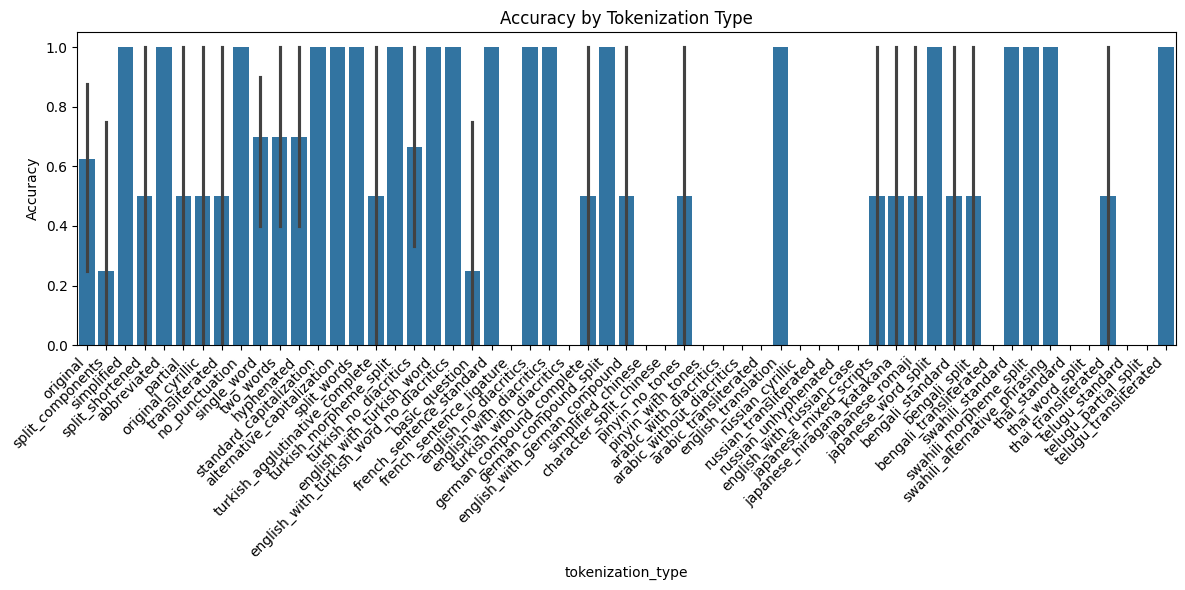

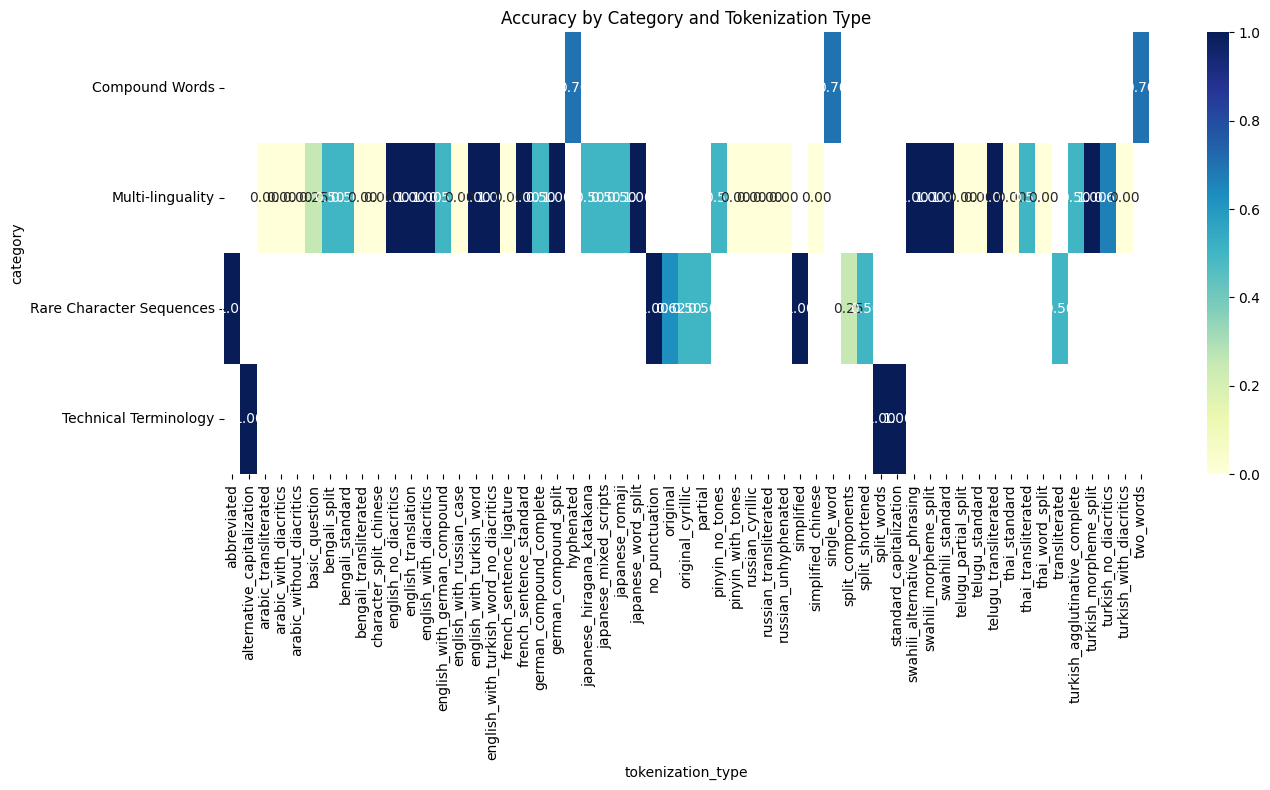

In [ ]:
df = all_preds.copy()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your dataframe is called df
# First, let's calculate some basic statistics

# 1. Overall accuracy
overall_accuracy = df["multi_target_match"].mean()
print(f"Overall accuracy: {overall_accuracy:.2%}")

# 2. Accuracy by tokenization type
tokenization_accuracy = df.groupby("tokenization_type")["multi_target_match"].agg(
    ["mean", "count"]
)
tokenization_accuracy = tokenization_accuracy.sort_values("mean", ascending=False)
print("\nAccuracy by tokenization type:")
print(tokenization_accuracy)

# 3. Accuracy by category
category_accuracy = df.groupby("category")["multi_target_match"].agg(["mean", "count"])
category_accuracy = category_accuracy.sort_values("mean", ascending=False)
print("\nAccuracy by category:")
print(category_accuracy)


# 4. Consistency analysis (within set_id)
def calculate_consistency(group):
    # If all correct or all wrong = perfect consistency (1.0)
    # Mix of correct/incorrect = lower consistency
    if len(group) <= 1:
        return 1.0
    correct_ratio = group["multi_target_match"].mean()
    if correct_ratio == 0 or correct_ratio == 1:
        return 1.0
    else:
        # 0 means half right, half wrong (least consistent)
        consistency = 1.0 - 2 * abs(0.5 - correct_ratio)
        return consistency


set_consistency = df.groupby("set_id").apply(calculate_consistency)
avg_consistency = set_consistency.mean()
print(f"\nAverage consistency across variants: {avg_consistency:.2%}")

# 5. Visualize tokenization impact
plt.figure(figsize=(12, 6))
sns.barplot(x="tokenization_type", y="multi_target_match", data=df)
plt.title("Accuracy by Tokenization Type")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.savefig("tokenization_accuracy.png")

# 6. Category-specific tokenization effects
plt.figure(figsize=(14, 8))
category_tokenization = (
    df.groupby(["category", "tokenization_type"])["multi_target_match"]
    .mean()
    .reset_index()
)
category_tokenization_pivot = category_tokenization.pivot(
    index="category", columns="tokenization_type", values="multi_target_match"
)
sns.heatmap(category_tokenization_pivot, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Accuracy by Category and Tokenization Type")
plt.tight_layout()
plt.savefig("category_tokenization_heatmap.png")

# 7. Identify problematic examples
problematic = df[df["multi_target_match"] == 0].sort_values(
    ["set_id", "tokenization_type"]
)
print("\nProblematic examples (incorrect responses):")
for _, row in problematic.iterrows():
    print(f"Set {row['set_id']} ({row['category']}) - {row['tokenization_type']}:")
    print(f"  Target: {row['target']}")
    print(f"  Response: {row['filtered_resps'][:100]}...")
    print()


# 8. Differential analysis: Find sets where tokenization makes a difference
def has_tokenization_impact(group):
    if len(group) <= 1:
        return False
    return group["multi_target_match"].min() != group["multi_target_match"].max()


impacted_sets = df.groupby("set_id").filter(has_tokenization_impact)
impacted_set_ids = impacted_sets["set_id"].unique()

print(
    f"\nSets with tokenization impact: {len(impacted_set_ids)}/{df['set_id'].nunique()}"
)
for set_id in impacted_set_ids:
    subset = df[df["set_id"] == set_id]
    print(f"\nSet {set_id} ({subset['category'].iloc[0]}):")
    for _, row in subset.iterrows():
        print(
            f"  {row['tokenization_type']}: {'✓' if row['multi_target_match'] == 1 else '✗'}"
        )
        if row["multi_target_match"] == 0:
            print(f"    Response: {row['filtered_resps'][:50]}...")

=== MODEL COMPARISON ===
Qwen/Qwen2.5-7B-Instruct: 69.41% accuracy (85 examples)
meta-llama/Meta-Llama-3.1-8B-Instruct: 50.59% accuracy (85 examples)

=== MODEL CONSISTENCY ===
Qwen/Qwen2.5-7B-Instruct: 89.58% consistency
meta-llama/Meta-Llama-3.1-8B-Instruct: 81.25% consistency


/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_47177/287182821.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  set_consistency = model_df.groupby('set_id').apply(calculate_consistency)
/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_47177/287182821.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  set_consistency = model_df.groupby('set_id').apply(calculate_consistency)
/var/f


=== TOKENIZATION IMPACT ===
meta-llama/Meta-Llama-3.1-8B-Instruct: 58.33% avg performance drop due to tokenization
Qwen/Qwen2.5-7B-Instruct: 33.33% avg performance drop due to tokenization

=== PROBLEMATIC SETS FOR Qwen/Qwen2.5-7B-Instruct ===
Sets with tokenization impact: 8/24

=== PROBLEMATIC SETS FOR meta-llama/Meta-Llama-3.1-8B-Instruct ===
Sets with tokenization impact: 14/24

Analysis complete! Summary report saved to tokenization_analysis/summary_report.md


/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_47177/287182821.py:141: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  set_delta = model_df.groupby('set_id').apply(tokenization_delta)
/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_47177/287182821.py:141: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  set_delta = model_df.groupby('set_id').apply(tokenization_delta)


{'model_info': {'Qwen/Qwen2.5-7B-Instruct': {'tokenizer': 'Qwen/Qwen2.5-7B-Instruct',
   'count': 85,
   'accuracy': 0.6941176470588235,
   'experiment': 'tok-robust-Qwen2.5-7B-Instruct'},
  'meta-llama/Meta-Llama-3.1-8B-Instruct': {'tokenizer': 'meta-llama/Meta-Llama-3.1-8B-Instruct',
   'count': 85,
   'accuracy': 0.5058823529411764,
   'experiment': 'tok-robust-Llama-3.1-8B-Instruct'}},
 'model_consistency': {'Qwen/Qwen2.5-7B-Instruct': 0.8958333333333334,
  'meta-llama/Meta-Llama-3.1-8B-Instruct': 0.8125},
 'model_deltas': {'Qwen/Qwen2.5-7B-Instruct': 0.3333333333333333,
  'meta-llama/Meta-Llama-3.1-8B-Instruct': 0.5833333333333334},
 'summary_file': 'tokenization_analysis/summary_report.md'}

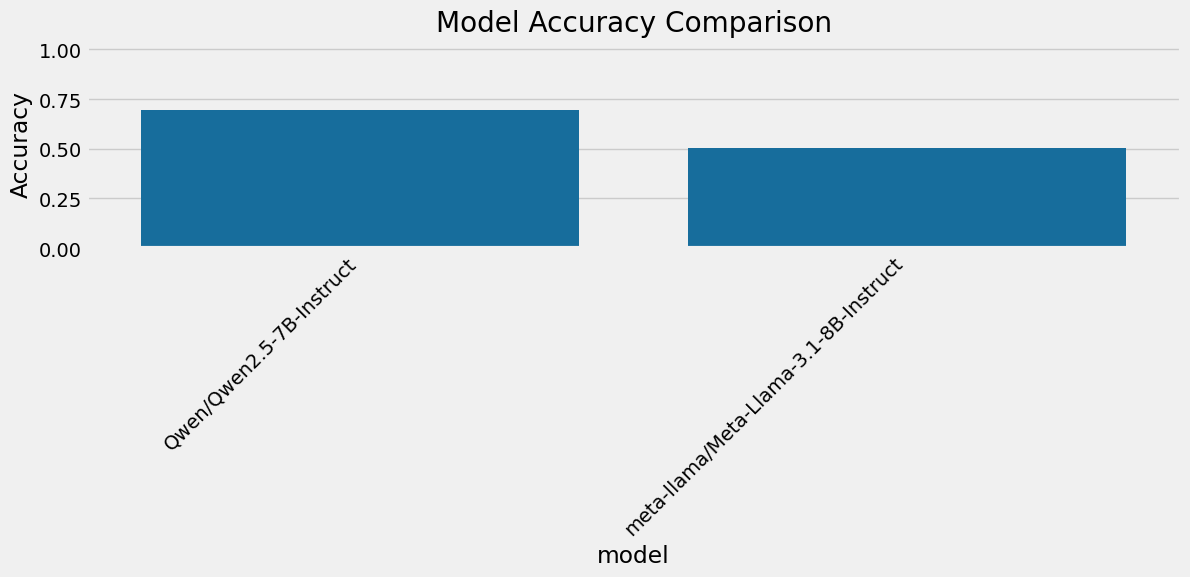

<Figure size 1400x800 with 0 Axes>

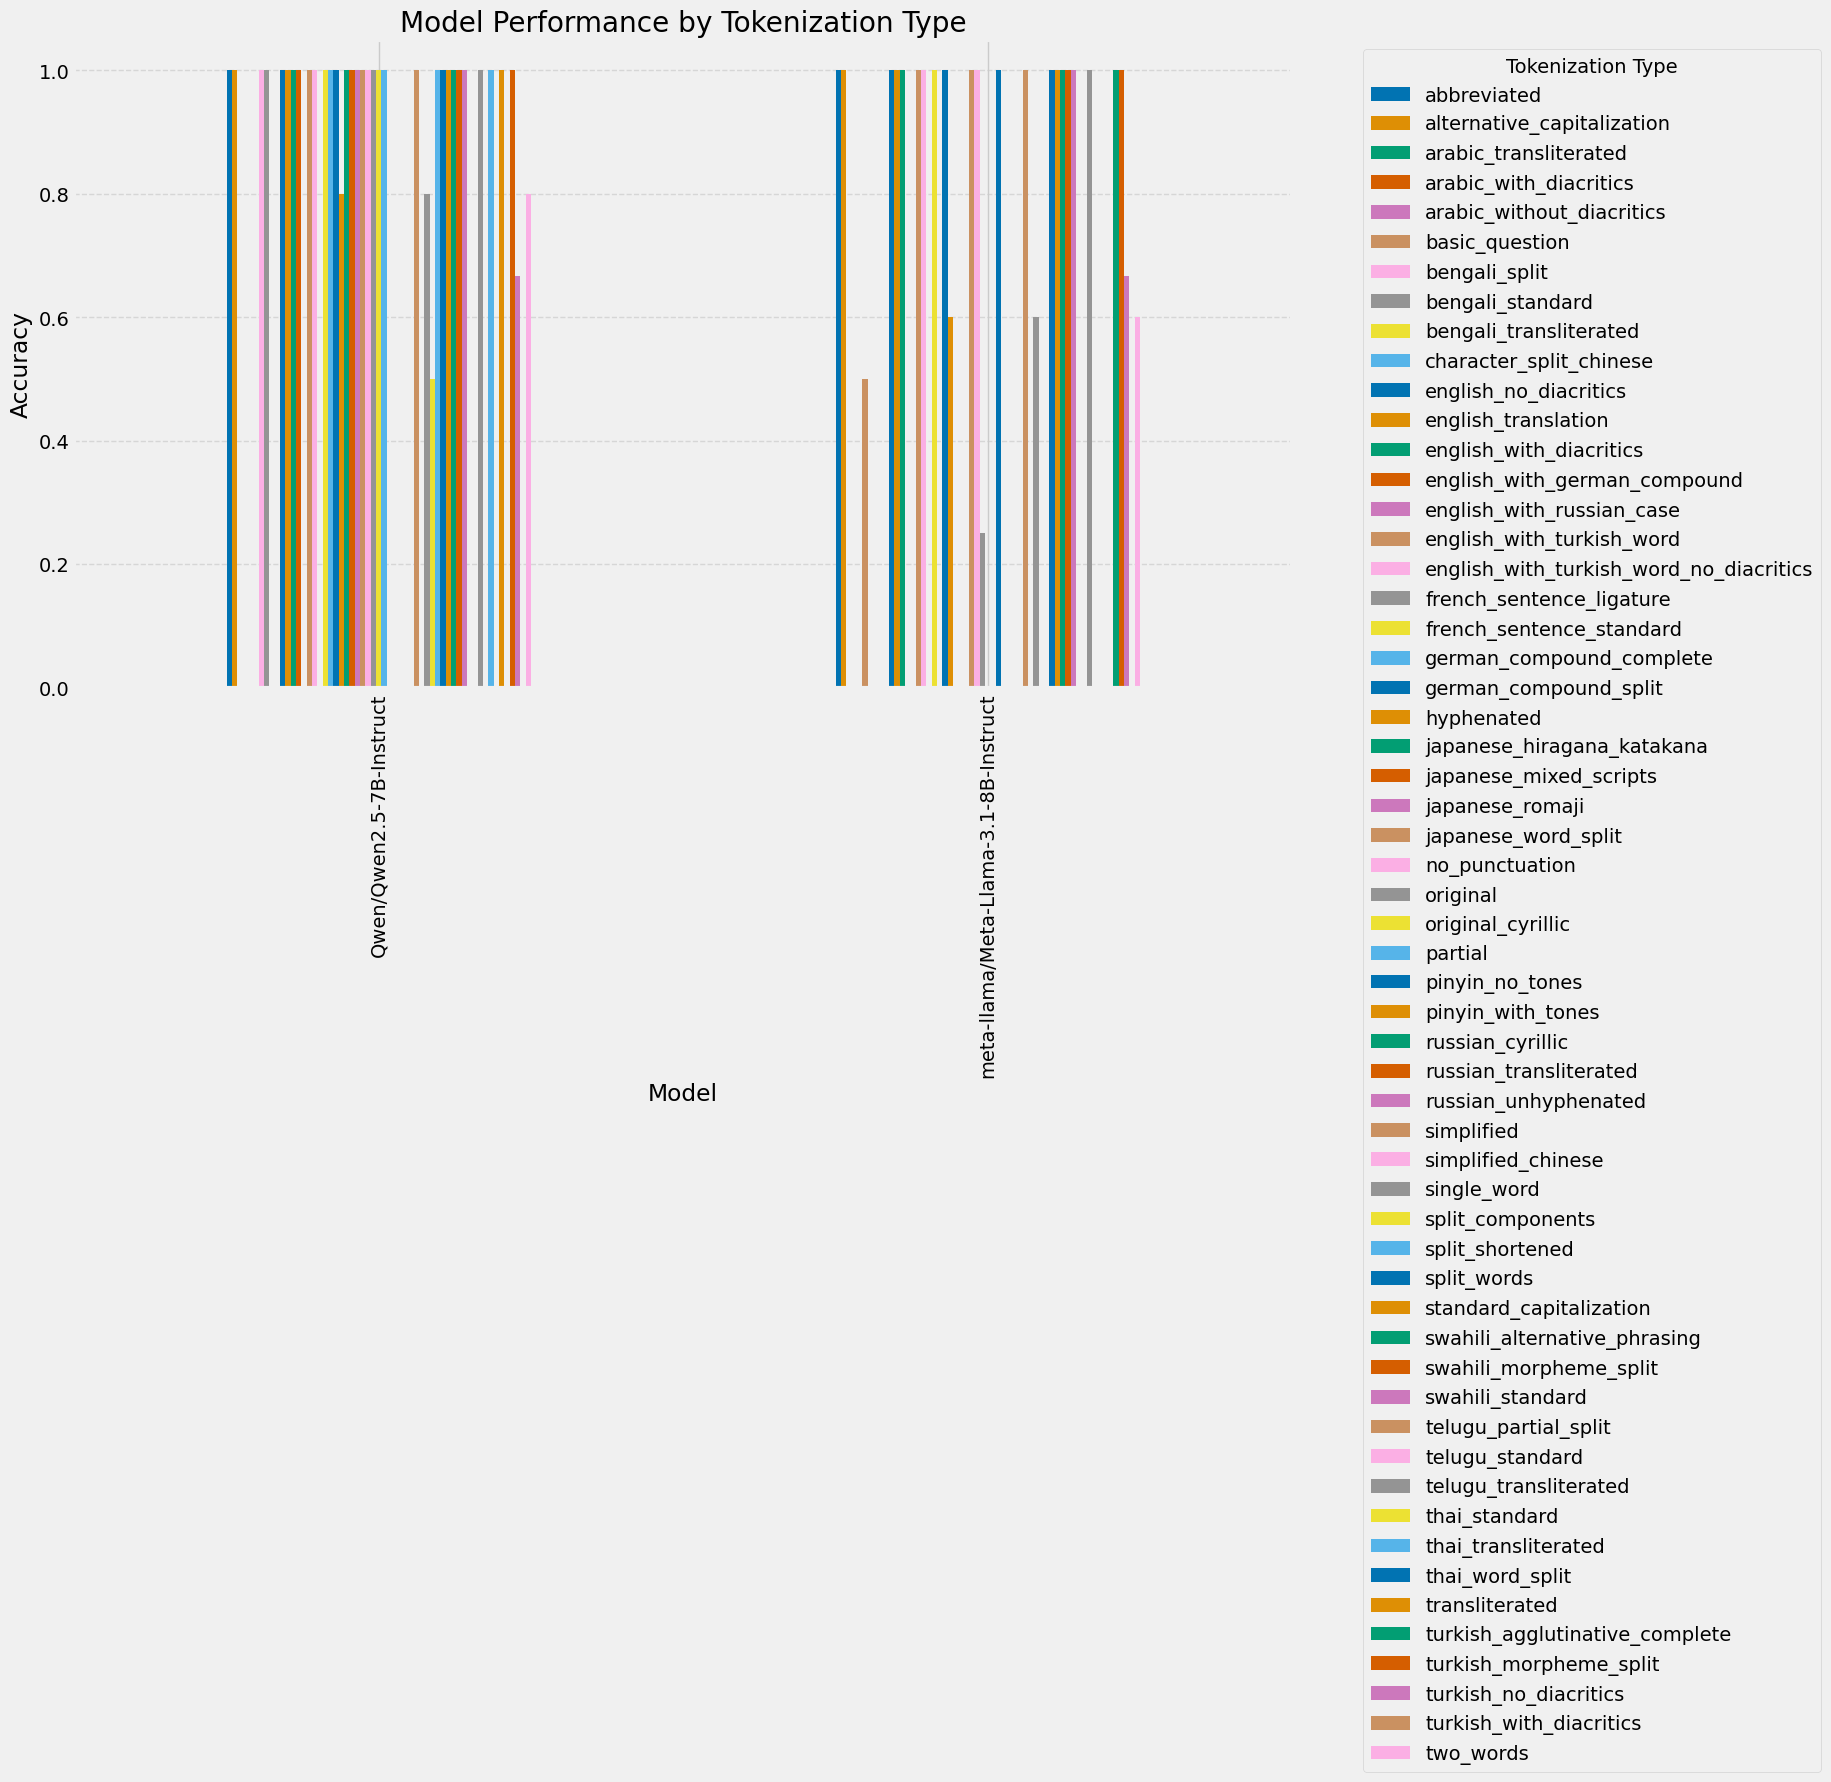

<Figure size 1400x800 with 0 Axes>

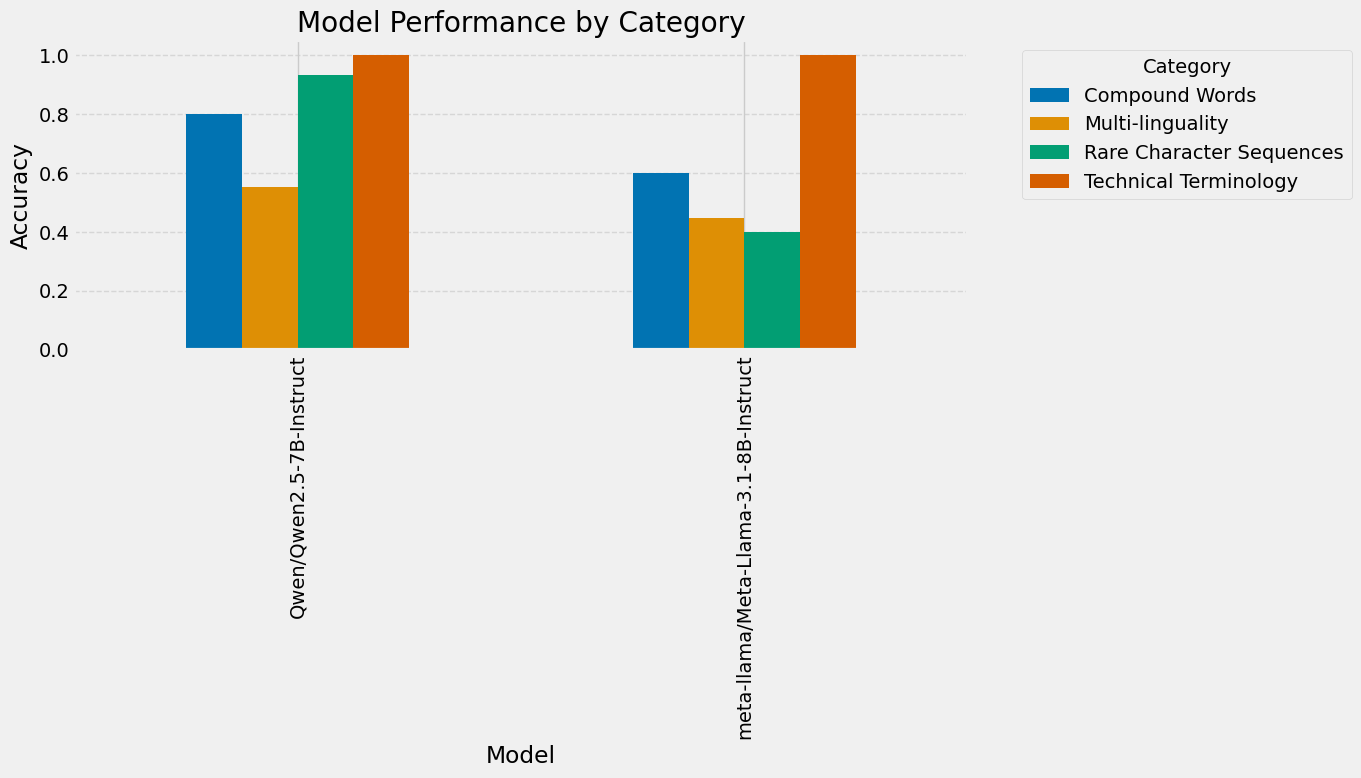

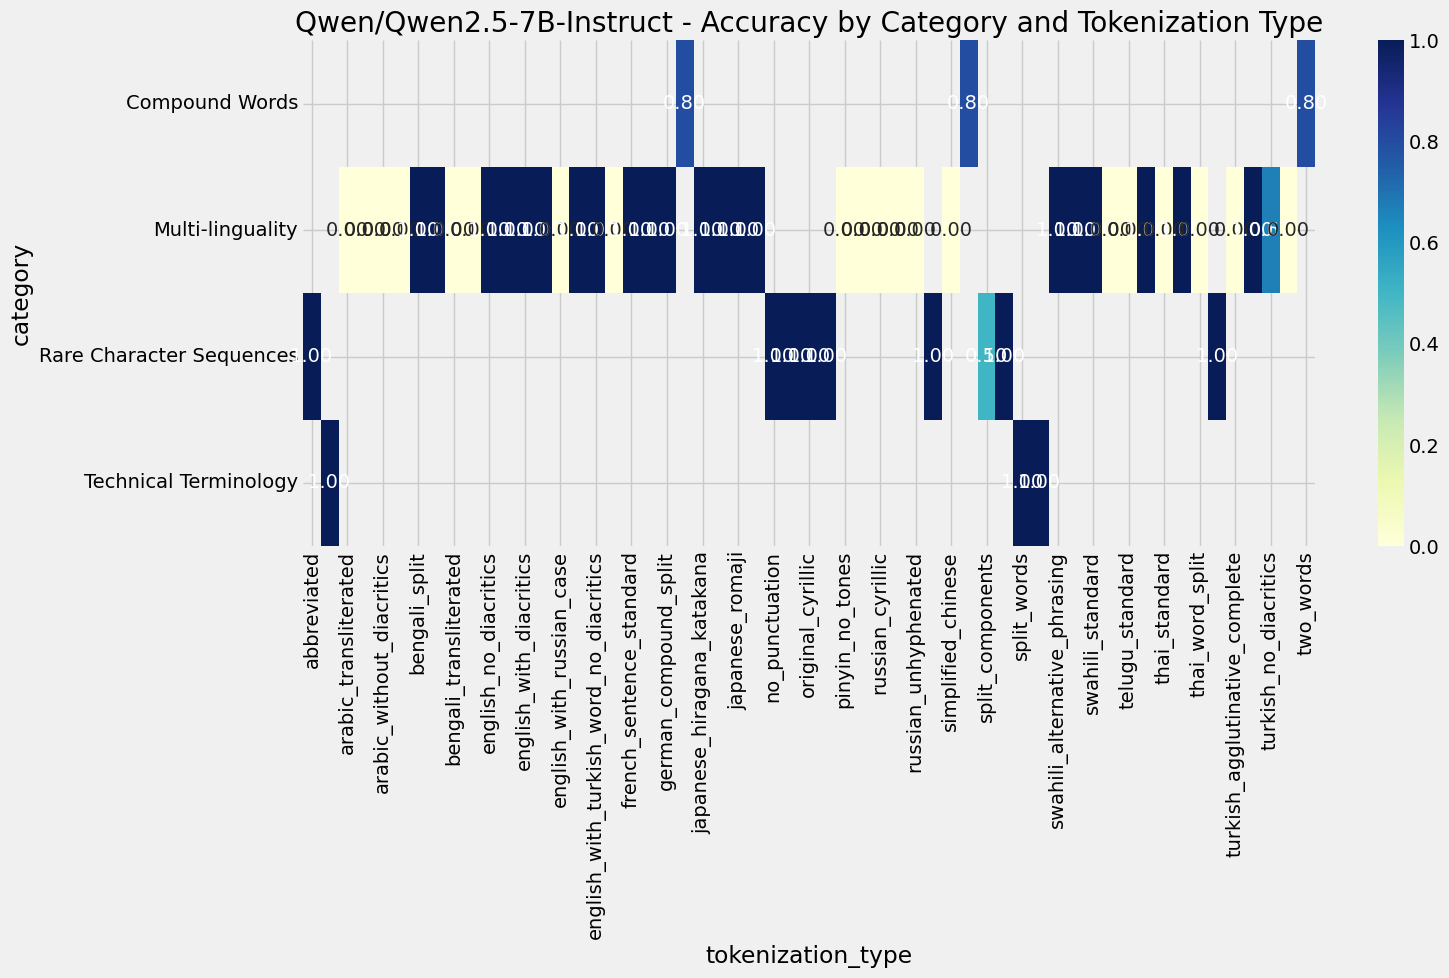

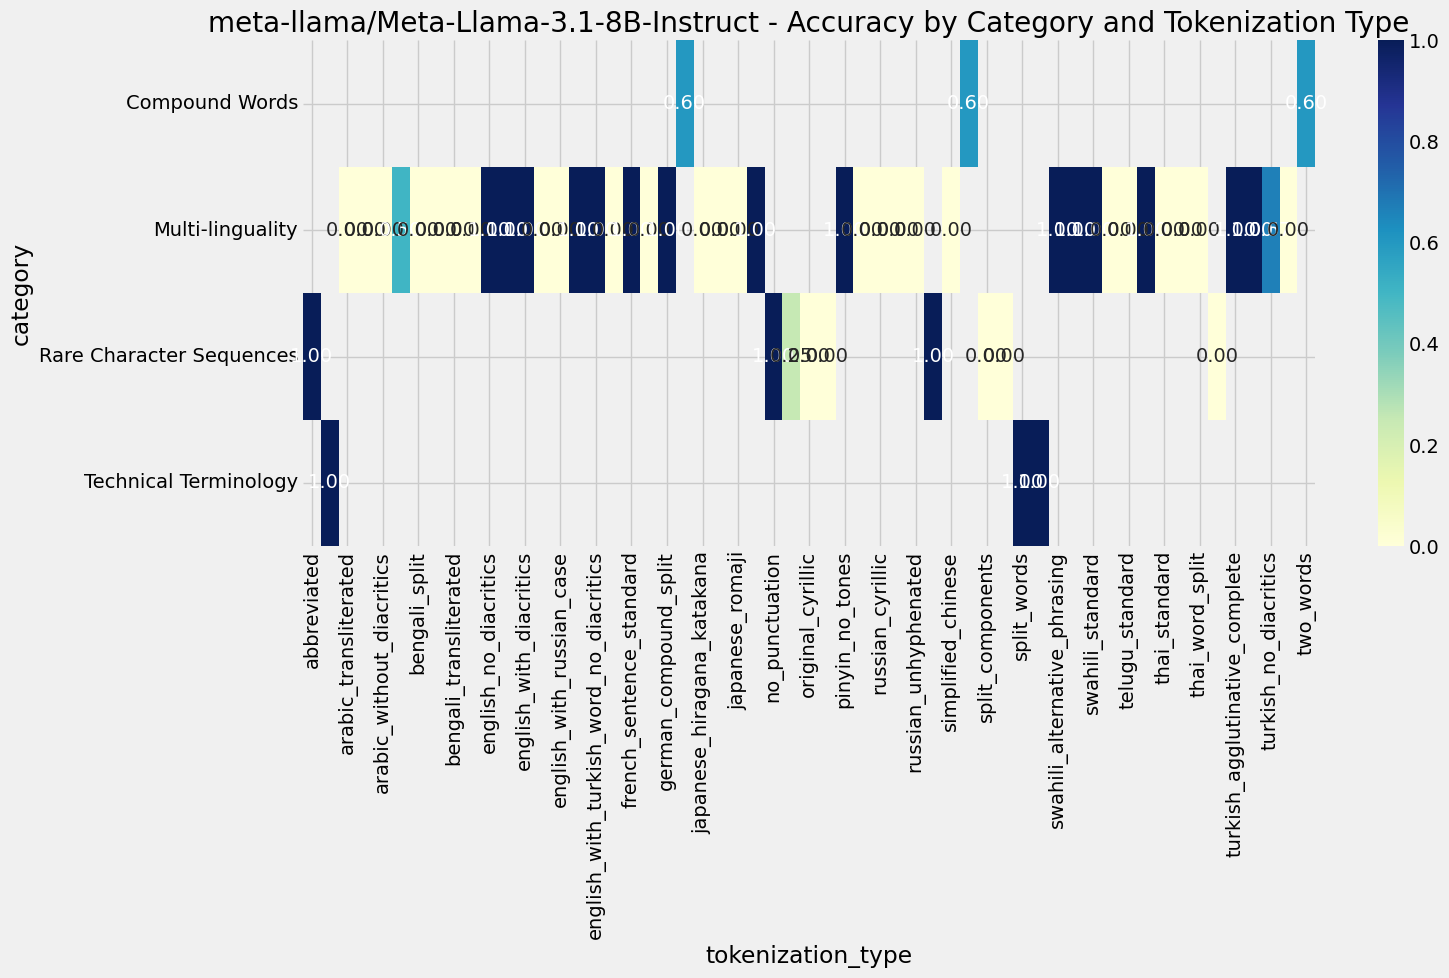

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

# Set style for better visualizations
plt.style.use("fivethirtyeight")
sns.set_palette("colorblind")


def analyze_tokenization_robustness(df, output_dir="tokenization_analysis"):
    """
    Analyze tokenization robustness from LM evaluation results

    Args:
        df: DataFrame with evaluation results
        output_dir: Directory to save analysis outputs
    """
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)

    # Extract model information
    models = df["model_name"].unique()
    model_info = {}

    for model in models:
        model_df = df[df["model_name"] == model]
        model_info[model] = {
            "tokenizer": model_df["tokenizer_name"].iloc[0],
            "count": len(model_df),
            "accuracy": model_df["multi_target_match"].mean(),
            "experiment": model_df["experiment_name"].iloc[0],
        }

    # 1. Model comparison overview
    print("=== MODEL COMPARISON ===")
    for model, info in sorted(
        model_info.items(), key=lambda x: x[1]["accuracy"], reverse=True
    ):
        print(f"{model}: {info['accuracy']:.2%} accuracy ({info['count']} examples)")

    # 2. Overall accuracy by model and tokenization type
    tokenization_by_model = df.groupby(["model_name", "tokenization_type"])[
        "multi_target_match"
    ].agg(["mean", "count"])

    # 3. Per-category analysis by model
    category_by_model = df.groupby(["model_name", "category"])[
        "multi_target_match"
    ].agg(["mean", "count"])

    # 4. Consistency analysis by model
    def calculate_consistency(group):
        if len(group) <= 1:
            return 1.0
        correct_ratio = group["multi_target_match"].mean()
        if correct_ratio == 0 or correct_ratio == 1:
            return 1.0
        else:
            consistency = 1.0 - 2 * abs(0.5 - correct_ratio)
            return consistency

    model_consistency = {}
    for model in models:
        model_df = df[df["model_name"] == model]
        set_consistency = model_df.groupby("set_id").apply(calculate_consistency)
        model_consistency[model] = set_consistency.mean()

    print("\n=== MODEL CONSISTENCY ===")
    for model, consistency in sorted(
        model_consistency.items(), key=lambda x: x[1], reverse=True
    ):
        print(f"{model}: {consistency:.2%} consistency")

    # 5. Visualizations

    # 5.1 Overall model comparison
    plt.figure(figsize=(12, 6))
    model_df = pd.DataFrame(
        [
            {"model": model, "accuracy": info["accuracy"]}
            for model, info in model_info.items()
        ]
    )
    sns.barplot(x="model", y="accuracy", data=model_df)
    plt.title("Model Accuracy Comparison")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "model_comparison.png"))

    # 5.2 Tokenization impact by model
    tokenization_pivot = (
        df.groupby(["model_name", "tokenization_type"])["multi_target_match"]
        .mean()
        .unstack()
    )

    plt.figure(figsize=(14, 8))
    tokenization_pivot.plot(kind="bar", figsize=(14, 8))
    plt.title("Model Performance by Tokenization Type")
    plt.xlabel("Model")
    plt.ylabel("Accuracy")
    plt.legend(title="Tokenization Type", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True, axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "model_tokenization_comparison.png"))

    # 5.3 Category performance by model
    category_pivot = (
        df.groupby(["model_name", "category"])["multi_target_match"].mean().unstack()
    )

    plt.figure(figsize=(14, 8))
    category_pivot.plot(kind="bar", figsize=(14, 8))
    plt.title("Model Performance by Category")
    plt.xlabel("Model")
    plt.ylabel("Accuracy")
    plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True, axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "model_category_comparison.png"))

    # 5.4 Heatmaps for each model
    for model in models:
        model_df = df[df["model_name"] == model]

        # Skip if too few examples
        if len(model_df) < 10:
            continue

        # Tokenization type vs category heatmap
        plt.figure(figsize=(16, 10))
        category_tokenization = (
            model_df.groupby(["category", "tokenization_type"])["multi_target_match"]
            .mean()
            .reset_index()
        )
        category_tokenization_pivot = category_tokenization.pivot(
            index="category", columns="tokenization_type", values="multi_target_match"
        )

        # Plot heatmap
        sns.heatmap(category_tokenization_pivot, annot=True, cmap="YlGnBu", fmt=".2f")
        plt.title(f"{model} - Accuracy by Category and Tokenization Type")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"{model.replace('/', '-')}_heatmap.png"))

    # 6. Tokenization impact analysis
    def tokenization_delta(group):
        if len(group) <= 1:
            return 0
        return group["multi_target_match"].max() - group["multi_target_match"].min()

    # Calculate delta for each model
    model_deltas = {}
    for model in models:
        model_df = df[df["model_name"] == model]
        set_delta = model_df.groupby("set_id").apply(tokenization_delta)
        model_deltas[model] = set_delta.mean()

    print("\n=== TOKENIZATION IMPACT ===")
    for model, delta in sorted(model_deltas.items(), key=lambda x: x[1], reverse=True):
        print(f"{model}: {delta:.2%} avg performance drop due to tokenization")

    # 7. Identify problematic sets for each model
    for model in models:
        model_df = df[df["model_name"] == model]

        # Find sets where tokenization makes a difference
        def has_tokenization_impact(group):
            if len(group) <= 1:
                return False
            return (
                group["multi_target_match"].min() != group["multi_target_match"].max()
            )

        impacted_sets = model_df.groupby("set_id").filter(has_tokenization_impact)
        impacted_set_ids = impacted_sets["set_id"].unique()

        if len(impacted_set_ids) > 0:
            print(f"\n=== PROBLEMATIC SETS FOR {model} ===")
            print(
                f"Sets with tokenization impact: {len(impacted_set_ids)}/{model_df['set_id'].nunique()}"
            )

            # Save detailed analysis to file
            with open(
                os.path.join(
                    output_dir, f"{model.replace('/', '-')}_problematic_sets.txt"
                ),
                "w",
            ) as f:
                f.write(f"PROBLEMATIC SETS FOR {model}\n")
                f.write(
                    f"Sets with tokenization impact: {len(impacted_set_ids)}/{model_df['set_id'].nunique()}\n\n"
                )

                for set_id in impacted_set_ids:
                    subset = model_df[model_df["set_id"] == set_id]
                    f.write(f"\nSet {set_id} ({subset['category'].iloc[0]}):\n")

                    for _, row in subset.iterrows():
                        f.write(
                            f"  {row['tokenization_type']}: {'✓' if row['multi_target_match'] == 1 else '✗'}\n"
                        )
                        if row["multi_target_match"] == 0:
                            f.write(f"    Response: {row['filtered_resps'][:100]}...\n")

    # 8. Generate overall summary report
    summary_file = os.path.join(output_dir, "summary_report.md")
    with open(summary_file, "w") as f:
        f.write("# Tokenization Robustness Analysis Report\n\n")
        f.write(f"*Generated on {datetime.now().strftime('%Y-%m-%d %H:%M')}*\n\n")

        f.write("## Model Performance\n\n")
        f.write("| Model | Accuracy | Consistency | Tokenization Impact |\n")
        f.write("|-------|----------|-------------|--------------------|\n")

        for model in sorted(
            models, key=lambda m: model_info[m]["accuracy"], reverse=True
        ):
            f.write(
                f"| {model} | {model_info[model]['accuracy']:.2%} | {model_consistency[model]:.2%} | {model_deltas[model]:.2%} |\n"
            )

        f.write("\n## Best Performing Tokenization Types\n\n")
        overall_tok_acc = (
            df.groupby("tokenization_type")["multi_target_match"]
            .mean()
            .sort_values(ascending=False)
        )

        f.write("| Tokenization Type | Accuracy |\n")
        f.write("|------------------|----------|\n")

        for tok_type, acc in overall_tok_acc.head(5).items():
            f.write(f"| {tok_type} | {acc:.2%} |\n")

        f.write("\n## Worst Performing Tokenization Types\n\n")

        f.write("| Tokenization Type | Accuracy |\n")
        f.write("|------------------|----------|\n")

        for tok_type, acc in overall_tok_acc.tail(5).items():
            f.write(f"| {tok_type} | {acc:.2%} |\n")

        f.write("\n## Category Performance\n\n")
        overall_cat_acc = (
            df.groupby("category")["multi_target_match"]
            .mean()
            .sort_values(ascending=False)
        )

        f.write("| Category | Accuracy |\n")
        f.write("|----------|----------|\n")

        for cat, acc in overall_cat_acc.items():
            f.write(f"| {cat} | {acc:.2%} |\n")

        f.write("\n## Key Findings\n\n")

        # Top model
        top_model = max(model_info.items(), key=lambda x: x[1]["accuracy"])
        f.write(
            f"1. **Best performing model**: {top_model[0]} with {top_model[1]['accuracy']:.2%} accuracy\n\n"
        )

        # Most robust model
        most_robust = min(model_deltas.items(), key=lambda x: x[1])
        f.write(
            f"2. **Most tokenization-robust model**: {most_robust[0]} with only {most_robust[1]:.2%} performance drop\n\n"
        )

        # Most problematic tokenization types
        f.write("3. **Most problematic tokenization types**:\n")
        for tok_type, acc in overall_tok_acc.tail(3).items():
            f.write(f"   - {tok_type}: {acc:.2%} accuracy\n")

        f.write("\n4. **Most problematic categories**:\n")
        for cat, acc in overall_cat_acc.tail(3).items():
            f.write(f"   - {cat}: {acc:.2%} accuracy\n")

        f.write("\n## Recommendations\n\n")
        f.write(
            "1. Focus on improving handling of the following tokenization patterns:\n"
        )
        for tok_type, acc in overall_tok_acc.tail(3).items():
            f.write(f"   - {tok_type}\n")

        f.write("\n2. Prioritize robustness improvements for these categories:\n")
        for cat, acc in overall_cat_acc.tail(3).items():
            f.write(f"   - {cat}\n")

        f.write(
            "\n3. Consider examining the architecture and pre-training approach of the most robust model to understand what contributes to its tokenization resilience.\n"
        )

    print(f"\nAnalysis complete! Summary report saved to {summary_file}")
    return {
        "model_info": model_info,
        "model_consistency": model_consistency,
        "model_deltas": model_deltas,
        "summary_file": summary_file,
    }


# Example usage:
# df = pd.read_csv('tokenization_results.csv')
results = analyze_tokenization_robustness(df)
results

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5'),
  Text(5, 0, '6'),
  Text(6, 0, '7'),
  Text(7, 0, '8'),
  Text(8, 0, '9'),
  Text(9, 0, '10'),
  Text(10, 0, '11'),
  Text(11, 0, '12'),
  Text(12, 0, '13'),
  Text(13, 0, '14'),
  Text(14, 0, '15'),
  Text(15, 0, '16'),
  Text(16, 0, '17'),
  Text(17, 0, '18'),
  Text(18, 0, '19'),
  Text(19, 0, '20'),
  Text(20, 0, '21'),
  Text(21, 0, '22'),
  Text(22, 0, '23'),
  Text(23, 0, '24')])

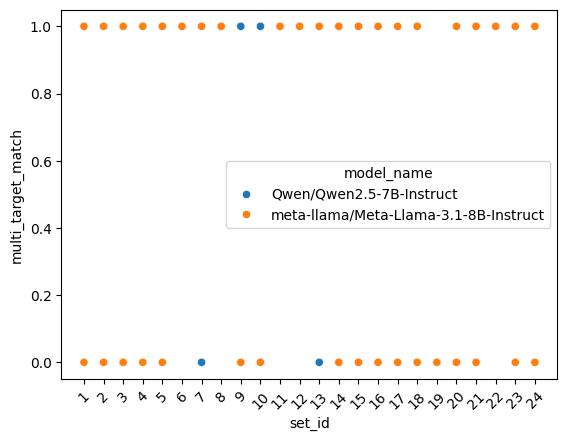

In [53]:
ax = sns.scatterplot(
    all_preds, x="set_id", y="multi_target_match", hue="model_name"
)  # , legend=False)
plt.xticks(rotation=45)